Preliminary Validation of the CardioBAN Wearable for ECG Waveform Accuracy: A DTW-Based Comparison with a Clinical Standard in Healthy Volunteers

Google Colab Notebook

This notebook implements the full data processing and analysis pipeline described in:

Escrivães et al., "First Evaluation of ECG Waveform Accuracy Using the CardioBAN Wearable." (2025).

In [ ]:
# ============================================================
# STEP 0 – Imports
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

# Known sampling frequency of CardioBAN
FS_CB = 1000.0  # Hz

# Folder where your CSVs are stored
DATA_ROOT = "" # define your folder with cardioban component
print("Dataset root folder:", DATA_ROOT)
print("Files in ECG_DATA:", os.listdir(DATA_ROOT))

# Map participants P1...P17 with both CardioBAN and GE files
participants = {}
for pid in range(1, 18):   # P1 ... P17
    p = f"P{pid}"
    cb_file = os.path.join(DATA_ROOT, f"{p}_CARDIOBAN.csv")
    ge_file = os.path.join(DATA_ROOT, f"{p}_GE_VIVID.csv")
    if os.path.exists(cb_file) and os.path.exists(ge_file):
        participants[p] = {"cardioban": cb_file, "ge": ge_file}

print("\nDetected participants and file paths:")
for pid, files in participants.items():
    print(f"  {pid}:")
    print(f"    CardioBAN: {files['cardioban']}")
    print(f"    GE Vivid : {files['ge']}")

# Choose one participant for quick visual checks in later steps
PID_PLOT = "P1"


In [ ]:
# ============================================================
# STEP 1 – Load signals and filter ONLY CardioBAN (1–150 Hz)
# ============================================================

def bandpass_filter_ecg(ecg, fs=FS_CB, low=1.0, high=150.0, order=4):
    """
    4th-order Butterworth band-pass filter (1–150 Hz).
    Used ONLY for the CardioBAN signal.
    """
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    ecg_filt = filtfilt(b, a, ecg)
    return ecg_filt

ecg_data = {}  # will store raw and filtered signals

for pid, files in participants.items():
    print(f"Loading {pid} ...")

    # CSVs with NO header: single column with ECG samples
    df_cb = pd.read_csv(files["cardioban"], header=None)
    df_ge = pd.read_csv(files["ge"], header=None)

    sig_cb_raw = df_cb.iloc[:, 0].astype(float).values  # CardioBAN raw
    sig_ge_raw = df_ge.iloc[:, 0].astype(float).values  # GE raw

    # Filter CardioBAN only
    sig_cb_filt = bandpass_filter_ecg(sig_cb_raw, fs=FS_CB)

    ecg_data[pid] = {
        "cardioban_raw": sig_cb_raw,
        "cardioban_filt": sig_cb_filt,
        "ge_raw": sig_ge_raw,
    }

print("\nSignals loaded and CardioBAN filtered for participants:")
print(list(ecg_data.keys()))


In [ ]:
# ============================================================
# QUICK PLOT AFTER STEP 1 – Raw vs Filtered CardioBAN + GE raw
# ============================================================

pid = PID_PLOT  # use the participant selected above

sig_cb_raw  = ecg_data[pid]["cardioban_raw"]
sig_cb_filt = ecg_data[pid]["cardioban_filt"]
sig_ge_raw  = ecg_data[pid]["ge_raw"]

fs = FS_CB
n_plot = min(3000, len(sig_cb_raw), len(sig_ge_raw))  # first 3000 samples (~3 s)
t = np.arange(n_plot) / fs

plt.figure(figsize=(14, 6))

plt.plot(t, sig_cb_raw[:n_plot], label="CardioBAN raw", alpha=0.5)
plt.plot(t, sig_cb_filt[:n_plot], label="CardioBAN filtered (1–150 Hz)", linewidth=1.2)

plt.title(f"{pid} – Raw vs Filtered (1–150 Hz) + GE raw")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# ============================================================
# STEP 2 – Amplitude normalization (z-score)
# ============================================================

def zscore(x):
    """
    Standard z-score normalization: mean = 0, std = 1.
    """
    x = np.asarray(x, float)
    m = np.mean(x)
    s = np.std(x)
    if s == 0:
        return x * 0.0
    return (x - m) / s

normalized_signals = {}

for pid, sigs in ecg_data.items():
    sig_cb = sigs["cardioban_filt"]  # filtered CardioBAN
    sig_ge = sigs["ge_raw"]          # raw GE

    sig_cb_norm = zscore(sig_cb)
    sig_ge_norm = zscore(sig_ge)

    normalized_signals[pid] = {
        "sig_cb_norm": sig_cb_norm,  # CardioBAN filtered + normalized
        "sig_ge_norm": sig_ge_norm,  # GE raw + normalized
        "fs_common": FS_CB           # we assume 1000 Hz as base for CardioBan
    }

print("Normalized signals created for participants:")
print(list(normalized_signals.keys()))


Normalized signals created for participants:
['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17']


In [ ]:
# ============================================================
# QUICK PLOT AFTER STEP 2 – Normalized signals (z-score)
# ============================================================

pid = PID_PLOT
ns = normalized_signals[pid]
fs = ns["fs_common"]

n_plot = min(5000, len(ns["sig_cb_norm"]), len(ns["sig_ge_norm"]))
t = np.arange(n_plot) / fs

plt.figure(figsize=(14, 5))
plt.plot(t, ns["sig_cb_norm"][:n_plot], label="CardioBAN (filtered + z-score)", linewidth=1.2)
plt.plot(t, ns["sig_ge_norm"][:n_plot], label="GE (raw + z-score)", alpha=0.8)
plt.title(f"{pid} – Normalized ECG (first {n_plot} samples)")
plt.xlabel("Time (s)")
plt.ylabel("Normalized amplitude (z-score)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w)/w, mode='same')


In [ ]:
def detect_r_peaks_universal(ecg_norm,
                             fs,
                             ma_qrs_ms=120,
                             ma_slope_ms=30,
                             min_rr_ms=250,
                             thresh_scale=0.5):
    """
    UNIVERSAL ROBUST R-PEAK DETECTOR
    Works for filtered CardioBAN and raw GE.

    Steps:
      - derivative
      - squared derivative
      - QRS integration window (moving average)
      - dynamic threshold = thresh_scale * max(integrated)
      - enforce refractory period (min_rr_ms)
      - final validation on ECG amplitude to ensure real R-waves
    """

    # 1) derivative
    diff = np.diff(ecg_norm, prepend=ecg_norm[0])

    # 2) squared derivative
    sq = diff ** 2

    # 3) integrate over a typical QRS length (120 ms)
    w_qrs = max(1, int(ma_qrs_ms * fs / 1000.0))
    qrs_int = moving_average(sq, w_qrs)

    # 4) slope enhancement (30 ms window)
    w_slope = max(1, int(ma_slope_ms * fs / 1000.0))
    slope = moving_average(np.abs(diff), w_slope)

    # 5) combined detection function
    detect_signal = qrs_int * slope

    # 6) dynamic threshold
    thr = thresh_scale * np.max(detect_signal)

    # 7) detect peaks in combined function
    min_dist = int(min_rr_ms * fs / 1000.0)
    peaks, props = find_peaks(detect_signal, height=thr, distance=min_dist)

    # 8) final validation: amplitude filter (ECG must be > 0.5 z-score)
    good = np.where(np.abs(ecg_norm[peaks]) >= 0.5)[0]
    peaks = peaks[good]

    return peaks, detect_signal


In [ ]:
r_peaks_by_pid = {}

for pid, ns in normalized_signals.items():
    sig_cb = ns["sig_cb_norm"]
    sig_ge = ns["sig_ge_norm"]
    fs = ns["fs_common"]

    # UNIVERSAL detector for CardioBAN
    r_cb, det_cb = detect_r_peaks_universal(
        sig_cb,
        fs,
        ma_qrs_ms=110,     # empirically defined
        ma_slope_ms=30,    # empirically defined
        min_rr_ms=280,     # empirically defined
        thresh_scale=0.35   # CB normally very clean after filter - empirically defined
    )

    # UNIVERSAL detector for GE
    r_ge, det_ge = detect_r_peaks_universal(
        sig_ge,
        fs,
        ma_qrs_ms=120,     # empirically defined
        ma_slope_ms=35,    # empirically defined
        min_rr_ms=300,     # empirically defined
        thresh_scale=0.25   # GE needs LOWER threshold behaviour - empirically defined
    )

    r_peaks_by_pid[pid] = {
        "cb": r_cb,
        "ge": r_ge,
        "detect_cb": det_cb,
        "detect_ge": det_ge,
    }

print("UNIVERSAL R-peak detection completed.")


UNIVERSAL R-peak detection completed.


In [ ]:
pid_plot = "P1"

sig_cb = normalized_signals[pid_plot]["sig_cb_norm"]
sig_ge = normalized_signals[pid_plot]["sig_ge_norm"]

r_cb = r_peaks_by_pid[pid_plot]["cb"]
r_ge = r_peaks_by_pid[pid_plot]["ge"]

det_cb = r_peaks_by_pid[pid_plot]["detect_cb"]
det_ge = r_peaks_by_pid[pid_plot]["detect_ge"]

N_SAMPLES = 3000
n = min(N_SAMPLES, len(sig_cb), len(sig_ge))
t = np.arange(n)

plt.figure(figsize=(14,10))

# 1) CardioBAN
plt.subplot(3,1,1)
plt.plot(t, sig_cb[:n])
plt.plot(r_cb[r_cb<n], sig_cb[r_cb[r_cb<n]], "ro")
plt.title("CardioBAN ECG (z-score) + universal R-peaks")
plt.grid(True)

# 2) GE
plt.subplot(3,1,2)
plt.plot(t, sig_ge[:n])
plt.plot(r_ge[r_ge<n], sig_ge[r_ge[r_ge<n]], "ro")
plt.title("GE ECG (z-score) + universal R-peaks")
plt.grid(True)

# 3) Detection function
plt.subplot(3,1,3)
plt.plot(t, det_cb[:n]/np.max(det_cb[:n]), label="CB detect fn (norm)")
plt.plot(t, det_ge[:n]/np.max(det_ge[:n]), label="GE detect fn (norm)", alpha=0.7)
plt.legend()
plt.title("QRS detection function")
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# STEP 4 – R-peak matching between CardioBAN and GE
# ============================================================

import numpy as np

def match_r_peaks(r_cb, r_ge, fs, max_pair_diff_ms=150):
    """
    Match R-peaks between CardioBAN (CB) and GE based on temporal proximity.

    For each R-peak in CB:
      - find the closest R-peak in GE
      - keep the pair only if |Δt| <= max_pair_diff_ms

    Returns:
      r_cb_match : numpy array of CB R-peak indices
      r_ge_match : numpy array of GE R-peak indices
    Both arrays have the same length (number of matched beats).
    """
    max_diff_samples = int(max_pair_diff_ms * fs / 1000.0)

    r_cb_match = []
    r_ge_match = []

    for r in r_cb:
        if len(r_ge) == 0:
            break
        # index of closest GE peak
        idx_near = np.argmin(np.abs(r_ge - r))
        if np.abs(r_ge[idx_near] - r) <= max_diff_samples:
            r_cb_match.append(r)
            r_ge_match.append(r_ge[idx_near])

    return np.array(r_cb_match, dtype=int), np.array(r_ge_match, dtype=int)


In [ ]:
# ============================================================
# STEP 4 – QRS-BY-QRS SEGMENTATION (index-based pairing)
# ------------------------------------------------------------
# Uses:
#   normalized_signals[pid]["sig_cb_norm"], ["sig_ge_norm"]
#   r_peaks_by_pid[pid]["cb"], ["ge"]  (robust R-peak detector)
#
# For each i-th R-peak:
#   CardioBAN: segment = [R_cb - PRE, R_cb + POST]
#   GE Vivid : segment = [R_ge - PRE, R_ge + POST]
# Then:
#   - discard segments that go out of bounds
#   - truncate both segments to the same length (min length)
#   - store them as paired QRS beats in qrs_pairs[pid]
# ============================================================

import numpy as np

if "normalized_signals" not in globals() or len(normalized_signals) == 0:
    raise RuntimeError("normalized_signals not found. Run loading + normalization first.")
if "r_peaks_by_pid" not in globals() or len(r_peaks_by_pid) == 0:
    raise RuntimeError("r_peaks_by_pid not found. Run R-peak detection first.")

# Window around each R-peak (in SAMPLES, not ms)
# You can also define these from fs, e.g. 0.15s and 0.25s.
QRS_PRE_SAMPLES  = 150   # samples before R (~150 ms at 1000 Hz)
QRS_POST_SAMPLES = 250   # samples after R  (~250 ms at 1000 Hz)

qrs_pairs = {}

for pid, sigs in normalized_signals.items():
    if pid not in r_peaks_by_pid:
        print(f"[WARNING] {pid}: no R-peaks, skipping.")
        continue

    sig_cb = sigs["sig_cb_norm"]
    sig_ge = sigs["sig_ge_norm"]

    r_cb_all = np.asarray(r_peaks_by_pid[pid]["cb"], dtype=int)
    r_ge_all = np.asarray(r_peaks_by_pid[pid]["ge"], dtype=int)

    # Pair i-th CB R-peak with i-th GE R-peak
    n_pairs = min(len(r_cb_all), len(r_ge_all))
    if n_pairs == 0:
        print(f"[WARNING] {pid}: no beat pairs, skipping.")
        continue

    qrs_cb_list = []
    qrs_ge_list = []
    r_cb_used = []
    r_ge_used = []

    for i in range(n_pairs):
        r_cb = r_cb_all[i]
        r_ge = r_ge_all[i]

        start_cb = r_cb - QRS_PRE_SAMPLES
        end_cb   = r_cb + QRS_POST_SAMPLES
        start_ge = r_ge - QRS_PRE_SAMPLES
        end_ge   = r_ge + QRS_POST_SAMPLES

        # Bounds check for both signals
        if start_cb < 0 or end_cb > len(sig_cb):
            continue
        if start_ge < 0 or end_ge > len(sig_ge):
            continue

        seg_cb = sig_cb[start_cb:end_cb]
        seg_ge = sig_ge[start_ge:end_ge]

        # Force same length → truncate to minimum length
        L = min(len(seg_cb), len(seg_ge))
        if L <= 10:
            continue  # too short, likely invalid

        qrs_cb_list.append(seg_cb[:L])
        qrs_ge_list.append(seg_ge[:L])
        r_cb_used.append(r_cb)
        r_ge_used.append(r_ge)

    print(f">>> {pid}: QRS pairs built = {len(qrs_cb_list)}")

    qrs_pairs[pid] = {
        "qrs_cb": qrs_cb_list,                 # list of numpy arrays (CardioBAN beats)
        "qrs_ge": qrs_ge_list,                 # list of numpy arrays (GE beats)
        "r_cb": np.array(r_cb_used, dtype=int),
        "r_ge": np.array(r_ge_used, dtype=int),
    }

print("\nQRS segmentation completed for all participants.")


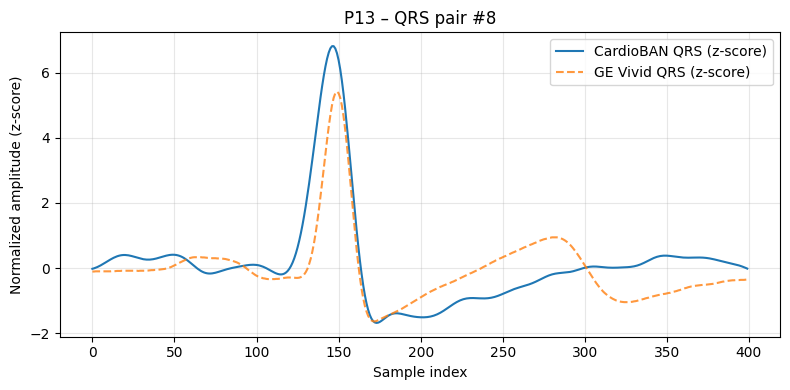

In [ ]:
# ============================================================
# QUICK PLOT AFTER STEP 4 – One QRS pair (CB vs GE)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

pid_plot = 'P13'  # e.g. "P1"
if pid_plot not in qrs_pairs:
    raise RuntimeError(f"{pid_plot} not found in qrs_pairs. Check segmentation.")

data = qrs_pairs[pid_plot]

if len(data["qrs_cb"]) == 0:
    raise RuntimeError(f"No QRS pairs for {pid_plot}.")

k = min(10, len(data["qrs_cb"]) - 1)  # choose beat index (0,1,2,...)

cb = np.asarray(data["qrs_cb"][k], float)
ge = np.asarray(data["qrs_ge"][k], float)

L = min(len(cb), len(ge))
t = np.arange(L)  # sample index (can be converted to ms if you want)

plt.figure(figsize=(8, 4))
plt.plot(t, cb[:L], label="CardioBAN QRS (z-score)")
plt.plot(t, ge[:L], label="GE Vivid QRS (z-score)", linestyle="--", alpha=0.8)

plt.title(f"{pid_plot} – QRS pair #{k}")
plt.xlabel("Sample index")
plt.ylabel("Normalized amplitude (z-score)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# STEP 5 – DTW RMSE BETWEEN QRS CYCLES (CardioBAN vs GE)
# ------------------------------------------------------------
# - Uses z-scored QRS cycles from qrs_pairs[pid]
# - Euclidean point-wise DTW cost (default in dtaidistance)
# - Sakoe–Chiba band: 10% of cycle length
# - Outputs RMSE along the DTW warping path:
#         RMSE_DTW = sqrt(total_cost / path_length)
# ============================================================

!pip install -q dtaidistance
from dtaidistance import dtw
import numpy as np
import pandas as pd

if "qrs_pairs" not in globals() or len(qrs_pairs) == 0:
    raise RuntimeError("qrs_pairs not found. Run QRS segmentation first.")

SAKOE_RATIO = 0.10  # 10% Sakoe–Chiba constraint


def dtw_rmse(cb, ge, sakoe_ratio=SAKOE_RATIO):
    """
    Compute RMSE-based DTW distance between two QRS cycles.

    Steps:
    1. Truncate both signals to same length (required by dtaidistance).
    2. Apply DTW with a Sakoe–Chiba band (window = sakoe_ratio * length).
    3. Retrieve warping path -> determine path length.
    4. Compute RMSE = sqrt(total_cost / path_length).
    """
    cb = np.asarray(cb, float)
    ge = np.asarray(ge, float)

    L = min(len(cb), len(ge))
    cb = cb[:L]
    ge = ge[:L]

    window = int(sakoe_ratio * L) if sakoe_ratio is not None else None

    # d = sqrt(total_cost)
    d, paths = dtw.warping_paths(
        cb, ge,
        window=window,
        use_pruning=True,
        use_c=True,
    )

    path = dtw.best_path(paths)
    if path is None or len(path) == 0:
        return np.nan

    path_len = len(path)
    rmse = float(d / np.sqrt(path_len))
    return rmse


In [ ]:
# ============================================================
# Compute DTW RMSE for all participants
# ============================================================

dtw_results = {}

for pid, data in qrs_pairs.items():
    qrs_cb_list = data["qrs_cb"]
    qrs_ge_list = data["qrs_ge"]

    n_beats = min(len(qrs_cb_list), len(qrs_ge_list))
    if n_beats == 0:
        print(f"[WARNING] {pid}: no QRS pairs, skipping.")
        continue

    dtw_vals = []
    for k in range(n_beats):
        rmse_val = dtw_rmse(qrs_cb_list[k], qrs_ge_list[k])
        if np.isfinite(rmse_val):
            dtw_vals.append(rmse_val)

    dtw_vals = np.array(dtw_vals)

    dtw_results[pid] = {
        "distances": dtw_vals,
        "n_pairs": len(dtw_vals),
    }

    print(f"{pid}: {len(dtw_vals)} DTW values "
          f"(mean={dtw_vals.mean():.3f}, median={np.median(dtw_vals):.3f})")


In [ ]:
# ============================================================
# TABLE 2 — WIDE FORMAT: one column per participant
# ============================================================

max_beats = max(len(v["distances"]) for v in dtw_results.values())

# create dict for wide table
wide_data = {"BeatIndex": np.arange(1, max_beats + 1)}

for pid in sorted(dtw_results.keys()):
    vals = dtw_results[pid]["distances"]

    # pad with NaN for participants with fewer beats
    if len(vals) < max_beats:
        padded = list(vals) + [np.nan] * (max_beats - len(vals))
    else:
        padded = vals

    wide_data[pid] = padded

dtw_wide_df = pd.DataFrame(wide_data)
dtw_wide_df


In [ ]:
# ============================================================
# DTW ALIGNMENT PLOT (OVERLAID SIGNALS + MANY LINES)
# ============================================================

from dtaidistance import dtw
import numpy as np
import matplotlib.pyplot as plt

# ---- SELECT PARTICIPANT AND BEAT ----
pid_plot = "P17"     # e.g., P17, P4, P5…
beat_idx = 3         # index of QRS pair (0-based)

# ---- LOAD QRS SEGMENTS ----
cb = np.asarray(qrs_pairs[pid_plot]["qrs_cb"][beat_idx], float)
ge = np.asarray(qrs_pairs[pid_plot]["qrs_ge"][beat_idx], float)

# Ensure same length
L = min(len(cb), len(ge))
cb = cb[:L]
ge = ge[:L]

# ---- SAKOE–CHIBA BAND ----
SAKOE_RATIO = 0.10
window = int(SAKOE_RATIO * L)

# ---- DTW ----
d, paths = dtw.warping_paths(
    cb, ge,
    window=window,
    use_pruning=True,
    use_c=True,
)
path = dtw.best_path(paths)

# Path length and RMSE
path_len = len(path)
rmse = d / np.sqrt(path_len)

print(f"{pid_plot} – QRS #{beat_idx}")
print(f"  Raw DTW distance (d)      = {d:.4f}")
print(f"  Path length                = {path_len}")
print(f"  DTW RMSE (article metric)  = {rmse:.4f}")

# ---- PLOT ----
plt.figure(figsize=(12, 6))

t = np.arange(L)

# Plot both signals overlaid
plt.plot(t, cb, label="CardioBAN", linewidth=2)
plt.plot(t, ge, label="GE Vivid", linewidth=2, alpha=0.8)

# ---- DRAW MULTIPLE DTW LINES ----
# Draw ~120 lines maximum to keep plot readable
if len(path) > 0:
    step = max(1, len(path) // 200)

    for (i, j) in path[::step]:
        if i < L and j < L:
            plt.plot(
                [i, j],       # x-values
                [cb[i], ge[j]],  # y-values
                color="gray",
                alpha=0.25,
                linewidth=0.6
            )

plt.title(f"{pid_plot} – DTW Alignment (QRS #{beat_idx}, Sakoe 10%)\nDTW RMSE = {rmse:.4f}")
plt.xlabel("Sample index")
plt.ylabel("Amplitude (z-score)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# BUILD CLEAN SUMMARY TABLE
# ============================================================

import pandas as pd
import numpy as np

rows = []

for pid in sorted(dtw_results.keys()):
    vals = np.array(dtw_results[pid]["distances"])
    row = {
        "Participant": pid,
        "Cycles": len(vals),
        "Mean": round(float(vals.mean()), 3),
        "Median": round(float(np.median(vals)), 3),
        "Min": round(float(vals.min()), 3),
        "Max": round(float(vals.max()), 3),
    }
    rows.append(row)

summary_df = pd.DataFrame(rows)

# ---- GLOBAL STATS ----
global_stats = pd.DataFrame({
    "Statistic": ["Average", "Std Dev", "Minimum", "Maximum"],
    "Mean": [
        round(summary_df["Mean"].mean(), 3),
        round(summary_df["Mean"].std(), 3),
        round(summary_df["Mean"].min(), 3),
        round(summary_df["Mean"].max(), 3)
    ],
    "Median": [
        round(summary_df["Median"].mean(), 3),
        round(summary_df["Median"].std(), 3),
        round(summary_df["Median"].min(), 3),
        round(summary_df["Median"].max(), 3)
    ],
    "Min": [
        round(summary_df["Min"].mean(), 3),
        round(summary_df["Min"].std(), 3),
        round(summary_df["Min"].min(), 3),
        round(summary_df["Min"].max(), 3)
    ],
    "Max": [
        round(summary_df["Max"].mean(), 3),
        round(summary_df["Max"].std(), 3),
        round(summary_df["Max"].min(), 3),
        round(summary_df["Max"].max(), 3)
    ]
})

summary_df, global_stats


In [ ]:
# ============================================================
# DTW RMSE + ALIGNED SEQUENCES + GLOBAL / PER-PID BLAND–ALTMAN
# ============================================================

# 1) Imports
!pip install -q dtaidistance

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dtaidistance import dtw

# ------------------------------------------------------------
# 2) DTW RMSE function (with optional aligned sequences)
# ------------------------------------------------------------

SAKOE_RATIO = 0.10  # 10% Sakoe–Chiba band

def dtw_rmse(cb, ge, sakoe_ratio=SAKOE_RATIO, return_aligned=False):
    """
    Compute DTW RMSE between two QRS cycles (CardioBAN vs GE)
    using a Sakoe–Chiba band (fraction of cycle length).

    If return_aligned=True, also returns:
      - aligned_cb: DTW-aligned CardioBAN samples
      - aligned_ge: DTW-aligned GE samples
    """
    cb = np.asarray(cb, float)
    ge = np.asarray(ge, float)

    # Truncate to same length before DTW
    L = min(len(cb), len(ge))
    if L == 0:
        if return_aligned:
            return np.nan, None, None
        return np.nan

    cb = cb[:L]
    ge = ge[:L]

    window = int(sakoe_ratio * L) if sakoe_ratio is not None else None

    # d = sqrt(total_cost)
    d, paths = dtw.warping_paths(
        cb, ge,
        window=window,
        use_pruning=True,
        use_c=True,
    )
    path = dtw.best_path(paths)

    if path is None or len(path) == 0:
        if return_aligned:
            return np.nan, None, None
        return np.nan

    path_len = len(path)
    rmse = float(d / np.sqrt(path_len))  # RMSE along DTW path

    if not return_aligned:
        return rmse

    # Build aligned sequences using the warping path
    aligned_cb = np.array([cb[i] for (i, j) in path], float)
    aligned_ge = np.array([ge[j] for (i, j) in path], float)

    return rmse, aligned_cb, aligned_ge


# ------------------------------------------------------------
# 3) Compute DTW RMSE (per beat) AND collect aligned points
# ------------------------------------------------------------

if "qrs_pairs" not in globals() or len(qrs_pairs) == 0:
    raise RuntimeError("qrs_pairs not found. Run QRS segmentation first.")

dtw_results = {}          # per-participant DTW RMSE summary
aligned_by_pid = {}       # aligned points per participant
all_cb_aligned_list = []  # global aligned CB samples
all_ge_aligned_list = []  # global aligned GE samples

for pid, data in qrs_pairs.items():
    qrs_cb_list = data["qrs_cb"]
    qrs_ge_list = data["qrs_ge"]

    n_beats = min(len(qrs_cb_list), len(qrs_ge_list))
    if n_beats == 0:
        print(f"[WARNING] {pid}: no QRS pairs, skipping.")
        continue

    dtw_vals = []
    pid_cb_aligned = []
    pid_ge_aligned = []

    print(f"Processing {pid} ({n_beats} QRS pairs)...")

    for k in range(n_beats):
        rmse_val, cb_al, ge_al = dtw_rmse(
            qrs_cb_list[k],
            qrs_ge_list[k],
            return_aligned=True
        )

        if not np.isfinite(rmse_val) or cb_al is None:
            continue

        # Store DTW RMSE per beat
        dtw_vals.append(rmse_val)

        # Accumulate aligned points (global)
        all_cb_aligned_list.append(cb_al)
        all_ge_aligned_list.append(ge_al)

        # Accumulate aligned points (per participant)
        pid_cb_aligned.append(cb_al)
        pid_ge_aligned.append(ge_al)

    if len(dtw_vals) == 0:
        print(f"[WARNING] {pid}: all DTW values invalid, skipping.")
        continue

    dtw_vals = np.array(dtw_vals, float)

    dtw_results[pid] = {
        "distances": dtw_vals,
        "n_pairs": len(dtw_vals),
    }

    if len(pid_cb_aligned) > 0:
        aligned_by_pid[pid] = {
            "cb": np.concatenate(pid_cb_aligned),
            "ge": np.concatenate(pid_ge_aligned),
        }

    print(f"{pid}: {len(dtw_vals)} DTW RMSE values "
          f"(mean={dtw_vals.mean():.3f}, median={np.median(dtw_vals):.3f})")

# Build global aligned arrays for Bland–Altman
if len(all_cb_aligned_list) == 0:
    raise RuntimeError("No aligned points collected. Check DTW / qrs_pairs.")

global_cb = np.concatenate(all_cb_aligned_list)
global_ge = np.concatenate(all_ge_aligned_list)

print("\nGLOBAL aligned samples:", len(global_cb))


# ------------------------------------------------------------
# 4) Bland–Altman function (stats + plot)
# ------------------------------------------------------------

def bland_altman(x, y, title="Bland–Altman", show=True, max_points_plot=5000):
    """
    Bland–Altman analysis between two arrays x and y.
    Returns bias, SD, and 95% limits of agreement.
    Optionally generates a BA plot (with subsampling if many points).
    """
    x = np.asarray(x, float)
    y = np.asarray(y, float)

    diffs = x - y
    means = (x + y) / 2

    bias = np.mean(diffs)
    sd = np.std(diffs, ddof=1)
    loa_low = bias - 1.96 * sd
    loa_high = bias + 1.96 * sd

    if show:
        plt.figure(figsize=(8, 5))
        step = max(1, len(diffs) // max_points_plot)
        plt.scatter(means[::step], diffs[::step], alpha=0.3, s=5)

        plt.axhline(bias, color="red", label=f"Bias = {bias:.3f}")
        plt.axhline(loa_low, color="gray", linestyle="--", label="LoA -1.96 SD")
        plt.axhline(loa_high, color="gray", linestyle="--", label="LoA +1.96 SD")

        plt.title(title)
        plt.xlabel("Mean amplitude (CardioBAN & GE)")
        plt.ylabel("Difference (CardioBAN − GE)")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {
        "bias": bias,
        "sd": sd,
        "loa_low": loa_low,
        "loa_high": loa_high,
    }


# ------------------------------------------------------------
# 5) GLOBAL Bland–Altman (ALL participants, ALL aligned points)
# ------------------------------------------------------------

ba_global = bland_altman(
    global_cb,
    global_ge,
    title="Global Bland–Altman after DTW alignment (all participants)"
)

print("\nGlobal Bland–Altman statistics:")
for k, v in ba_global.items():
    print(f"  {k}: {v:.4f}")



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Global point-wise error after DTW
errors = global_cb - global_ge

plt.figure(figsize=(5,6))
plt.violinplot(errors, showmeans=True, showmedians=True)
plt.xticks([1], ["Global"])
plt.ylabel("Error (CardioBAN – GE) [z-score]")
plt.title("Global Error Distribution after DTW alignment")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

errors = global_cb - global_ge

plt.figure(figsize=(4.5, 6))

# Boxplot sem outliers, estilo clean
bp = plt.boxplot(
    errors,
    vert=True,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"#1f77b4", "markeredgecolor":"black"},
    medianprops={"color":"black", "linewidth":1.5},
    boxprops={"linewidth":1.2},
    whiskerprops={"linewidth":1.2},
    capprops={"linewidth":1.2},
    flierprops={"marker":""}
)

# =============================
#  LIMITE AUTOMÁTICO DO EIXO Y
# =============================
# Usa os whiskers calculados pelo plot
whisker_low  = bp['whiskers'][0].get_ydata()[1]
whisker_high = bp['whiskers'][1].get_ydata()[1]

# margem pequena para ficar bonito
margin = 0.1 * (whisker_high - whisker_low)

plt.ylim([-0.7, 0.7])

# Títulos e labels
plt.xticks([1], ["Global"], fontsize=12)
plt.ylabel("Error (CardioBAN – GE) [z-score]", fontsize=12)
plt.title("Global Point-wise Error after DTW Alignment", fontsize=13)

plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

